In [1]:
import os
import csv
import re
import unicodedata
import warnings            
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
RUTA_NLTK_LOCAL = os.path.join(os.getcwd(), "palabras_nltk/", "nltk_data")

nltk.data.path = [RUTA_NLTK_LOCAL]

ruta_corpora_check = os.path.join(RUTA_NLTK_LOCAL, "corpora", "stopwords")
ruta_punkt_check = os.path.join(RUTA_NLTK_LOCAL, "tokenizers", "punkt_tab")

if not os.path.exists(ruta_corpora_check) or not os.path.exists(ruta_punkt_check):
    print("Iniciando descarga local")    
    os.makedirs(RUTA_NLTK_LOCAL, exist_ok=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        
        nltk.download('stopwords', download_dir=RUTA_NLTK_LOCAL, quiet=True)
        nltk.download('punkt_tab', download_dir=RUTA_NLTK_LOCAL, quiet=True)
    
    print("Descarga completada.")
else:
    print("\nRecursos NLTK detectados localmente.")


Iniciando descarga local
Descarga completada.


In [3]:
PALABRAS_A_IGNORAR = set(stopwords.words('spanish'))

PALABRAS_A_IGNORAR.update(['aca', 'buen', 'bueno', 'buena', 'etc', 'q', 'x', 'buenos', 'mas', 'si', 'tan', 'vi', 'asi', 'veo', 'dice', 'tener', 'vez', 'hace', 'hacer', 'tenes', 'dio', 'paso', 'hizo', 'ser', 'da', 're', 'ahi', 'hacen', 'ir', 'van', 'debe', 'solo', 'pasa', 'rio', 'decir', 'dos', 'estan', 'toda', 'cada', 'luego', 'claro', 'veces', 'deja', 'creo', 'ver', 'dijo', 'toda', 'jajaja', 'jajajaja', 'habia', 'sale', 'todas', 'tenia', 'aqui', 'demas', 'mismo', 'tambien', 'digo', 'podes', 'va', 'ahora', 'siempre', 'nunca', 'puede', 'despues', 'alguien', 'cosa', 'podemos', 'mucha', 'gran', 'igual', 'peor', 'antes', 'caso', 'sabe', 'mejor', 'bien', 'sos', 'ustedes', 'muchas', 'cosas', 'vaya', 'tipo', 'cosa', 'parte', 'manera', 'forma'])

In [4]:
def normalizar_texto(texto):
    """Transforma a minúsculas y remueve diacríticos manteniendo la eñe."""
    if not texto:
        return ""
    texto = texto.lower() 
    texto_descompuesto = unicodedata.normalize('NFD', texto)
    
    texto_limpio = "".join(
        c for c in texto_descompuesto 
        if unicodedata.category(c) != 'Mn' or c == '\u0303'
    )
    return unicodedata.normalize('NFC', texto_limpio)

In [5]:
def procesar_dataset(path_archivo, delimitador='|'):
    """Procesa el CSV usando el tokenizador de NLTK cargado localmente."""
    total_palabras_originales = 0
    palabras_filtradas_global = []
    solo_letras = re.compile(r'^[a-zñ]+$')

    with open(path_archivo, mode='r', encoding='utf-8') as archivo:
        lector = csv.reader(archivo, delimiter=delimitador)
        for fila in lector:
            if not fila or not "".join(fila).strip():
                continue
                
            texto_original = fila[0]
            texto_limpio = normalizar_texto(texto_original)
            
            tokens = word_tokenize(texto_limpio)
            total_palabras_originales += len(tokens)
            
            for token in tokens:
                if solo_letras.match(token):
                    if token not in PALABRAS_A_IGNORAR:
                        palabras_filtradas_global.append(token)
                    
    return total_palabras_originales, palabras_filtradas_global

-> Palabras originales (Tokens NLTK locales): 26768
-> Palabras filtradas: 10519
-> Palabras únicas finales: 4896

Top 25 palabras mas repetidas:
 1. programa: 152 veces
 2. fantino: 74 veces
 3. excelente: 70 veces
 4. gracias: 61 veces
 5. milei: 51 veces
 6. gente: 49 veces
 7. argentina: 47 veces
 8. años: 45 veces
 9. fanta: 43 veces
10. vos: 32 veces
11. trabajo: 32 veces
12. hablar: 30 veces
13. saludos: 30 veces
14. dia: 30 veces
15. pais: 29 veces
16. gobierno: 26 veces
17. otto: 25 veces
18. grande: 24 veces
19. impuestos: 23 veces
20. nadie: 22 veces
21. ozzy: 22 veces
22. agustin: 21 veces
23. hoy: 21 veces
24. mona: 20 veces
25. mundo: 20 veces


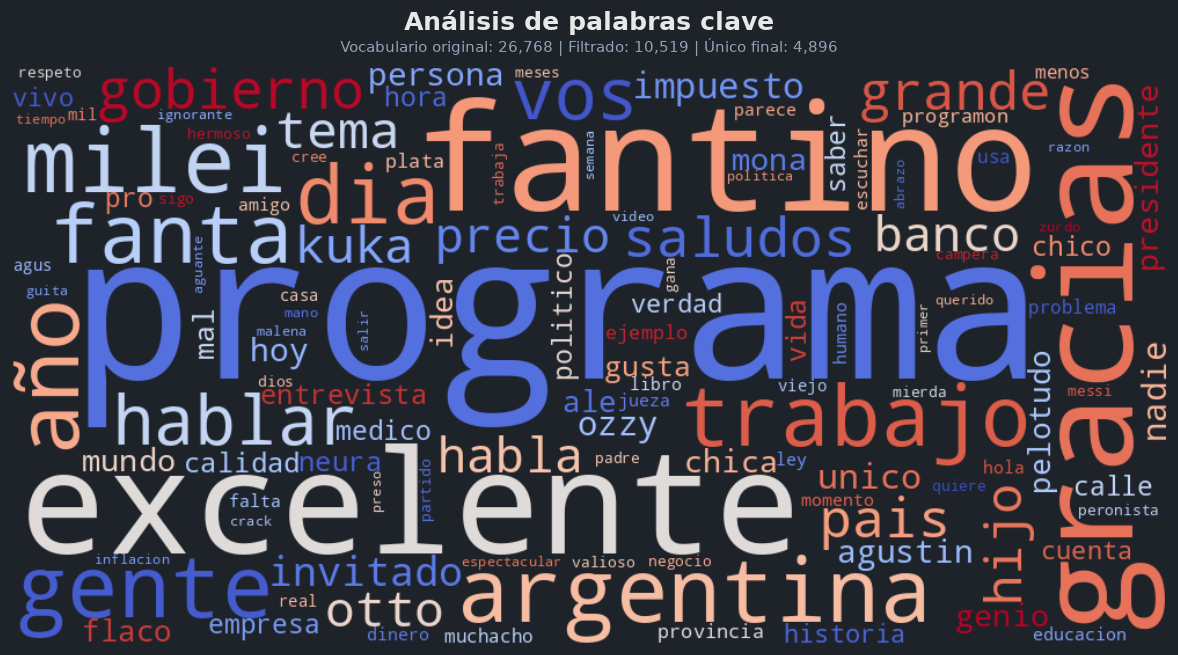

In [8]:
if __name__ == "__main__":
    archivo_csv = 'clasificados_limpio.csv'
    
    total_originales, palabras_filtradas = procesar_dataset(archivo_csv)

    total_despues_filtro = len(palabras_filtradas)
    unicas_despues_filtro = len(set(palabras_filtradas))
    
    print(f"-> Palabras originales (Tokens NLTK locales): {total_originales}")
    print(f"-> Palabras filtradas: {len(palabras_filtradas)}")
    print(f"-> Palabras únicas finales: {len(set(palabras_filtradas))}\n")
    
    conteo_palabras = Counter(palabras_filtradas)
    top_120 = conteo_palabras.most_common(120)
    
    print("Top 25 palabras mas repetidas:")
    for puesto, (palabra, frecuencia) in enumerate(top_120[:25], 1):
        print(f"{puesto:2d}. {palabra}: {frecuencia} veces")
        
    texto_para_nube = " ".join(palabras_filtradas)
    
    nube = WordCloud(
        width=1000, 
        height=500, 
        background_color='#1e2229',   
        colormap='coolwarm',           
        max_words=120, 
        collocations=False,                
        prefer_horizontal=0.85,
        random_state=842         
    ).generate(texto_para_nube)

    COLOR_FONDO = '#1e2229'
    
    fig, ax = plt.subplots(figsize=(12, 7), facecolor=COLOR_FONDO)
    ax.set_facecolor(COLOR_FONDO)
    
    ax.imshow(nube, interpolation='bilinear')
    ax.axis('off') 
    
    plt.suptitle(
        "Análisis de palabras clave", 
        color='#ffffff', 
        fontsize=18, 
        fontweight='bold', 
        y=0.96,                       
        alpha=0.9
    )
    
    ax.set_title(
        f"Vocabulario original: {total_originales:,} | Filtrado: {total_despues_filtro:,} | Único final: {unicas_despues_filtro:,}",
        color='#94a3b8',
        fontsize=11,
        pad=10
    )
    
    plt.tight_layout(pad=1.5)
    plt.savefig('nube_palabras.png', dpi=300, bbox_inches='tight', facecolor=COLOR_FONDO)
    plt.show()